**Sammanfattning:**
Allt för ofta plågas studenter med Word eller andra ordhanterare som
inte kan hantera ekvationer, figurer eller tabeller på ett tillförlitligt
och tillfredsställande sätt. Denna mall visar hur man med Quarto och
Jupyter Notebooks kan generera snygga PDF-rapporter via LaTeX.
Innehållet hamnar i fokus, inte formateringen.
Studera detta dokument och dess celler för att lära er hur det
är uppbyggt. Håll rapporten snygg, kort och koncis!

## Introduktion - Hur man skriver moderna rapporter

Denna mall använder [Quarto](https://quarto.org/) med Jupyter Notebooks för att generera PDF-rapporter via LaTeX. Till skillnad från Overleaf skriver vi i vanliga Jupyter Notebooks och använder LaTeX *enbart* för matematiska ekvationer. Quarto hanterar all formatering, numrering av sektioner, ekvationer och figurer samt referenshantering automatiskt.

### Installation

För att kunna rendera denna mall behövs:

1. **Python och Jupyter** installerat, se [installationsguiden](https://python.ju.se/python_installation.html)
2. **Quarto** installerat från [quarto.org](https://quarto.org/docs/get-started/). Välj "Install for me only" om du saknar administratörsrättigheter.
3. **En LaTeX-distribution** för PDF-rendering. Kontrollera om du redan har en med `pdflatex --version`. Om inte:
    - Linux: `sudo apt install texlive-full`
    - macOS: [MacTeX](https://tug.org/mactex/)
    - Windows: [MiKTeX](https://miktex.org/)
    - Alternativt TinyTeX (liten, ~250 MB): `quarto install tinytex`
4. **VS Code** med tilläggen [Quarto](https://marketplace.visualstudio.com/items?itemName=quarto.quarto) och [Jupyter](https://marketplace.visualstudio.com/items?itemName=ms-toolsai.jupyter)

Se [PDF Reports with LaTeX](https://python.ju.se/ProgrammingFundamentals/writing_documentation.html) för en fullständig genomgång av Quarto, LaTeX-matematik och felsökning.

### Arbetsflöde

1. Öppna denna notebook i VS Code
2. Redigera text i markdown-celler, lägg till ekvationer med LaTeX-syntax
3. Lägg till Python-kodceller för figurer och beräkningar
4. Rendera till PDF med ett av följande kommandon:

```bash
quarto preview report.ipynb --to pdf
```

`quarto preview` renderar PDF:en och öppnar den automatiskt. Dessutom bevakar den filen, så varje gång du sparar notebooken renderas PDF:en om och uppdateras. Perfekt under skrivandet, precis som Overleafs live-förhandsgranskning. Avsluta med `Ctrl+C` i terminalen.

```bash
quarto render report.ipynb --to pdf --execute
```

`quarto render` renderar PDF:en en gång utan bevakning. Flaggan `--execute` kör alla kodceller vid renderingen, vilket säkerställer reproducerbara resultat. Använd detta för slutversionen.

### Dokumentstruktur

Hela rapporten finns i en enda notebook-fil. Metadata (titel, författare, format) definieras i YAML-blocket i den första cellen (en *raw*-cell). Markdown-celler innehåller text och ekvationer, och kodceller genererar figurer och tabeller automatiskt.

## Figurer

Se @fig-chad, en graf av högsta kvalitet.

![Look at this graph](graphics/chad.jpg){#fig-chad width=60%}

### Hur hanterar vi figurer?

Titta på källkoden i notebook-cellerna för att se hur man inkluderar en figur med figurtext och referens. Syntaxen är:

```markdown
![Figurtext](sökväg/till/bild.jpg){#fig-etikett width=60%}
```

Referera sedan i texten med `@fig-etikett`. Quarto numrerar figurer automatiskt.

Vi tar alltid med figurtext och beskriver figurerna väl. Är det inte egenskapade figurer bör vi hänvisa till källan.

### Vektoriserad grafik

Sträva alltid efter att använda vektoriserade bilder (SVG, PDF) som kan skalas godtyckligt utan kvalitetsförlust. Man kan använda PowerPoint eller [Inkscape](https://inkscape.org/) för att skapa grafik och exportera som SVG.

**Fotografera aldrig en skärm.** Ett mobilfoto av en skärm ger moirérandor, färgstick, en sned bild och ibland din egen spegelbild. Ta en skärmbild i stället (Windows: Win+Skift+S, macOS: Cmd+Skift+4) och beskär den, så att läsaren ser figuren och inte ditt skrivbord och dina verktygsfält. Ännu bättre: använd programmets egen exportfunktion — CAD- och FEM-program kan spara bilder direkt, ofta som vektorgrafik.

### Figurer från Python-kod

En av Quartos stora styrkor är att Python-kod kan generera figurer direkt i rapporten. Nedanstående kodcell genererar @fig-sinuswave med följande Quarto-kommentarer:

```python
#| label: fig-sinuswave
#| fig-cap: "En sinusvåg genererad med Python"
#| echo: true
```

- `label: fig-sinuswave` gör figuren referensbar med `@fig-sinuswave`
- `fig-cap` sätter figurtexten
- `echo: true` visar koden i PDF:en (byt till `false` för att dölja den)

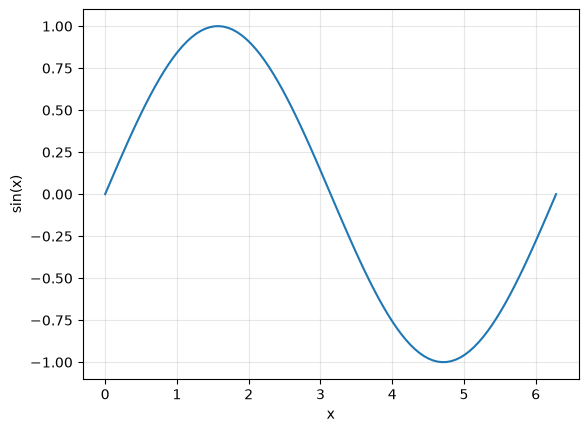

In [1]:
#| label: fig-sinuswave
#| fig-cap: "En sinusvåg genererad med Python"
#| echo: true

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2*np.pi, 100)
plt.plot(x, np.sin(x))
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.grid(True, alpha=0.3)
plt.show()

Kodcellen ovan använder Quarto-kommentarer (`#|`) för att kontrollera utseendet, se @tbl-kodcell.

| Alternativ | Effekt |
|-----------|--------|
| `#\| echo: true` | Visa koden (standard) |
| `#\| echo: false` | Dölj koden, visa bara figuren |
| `#\| output: false` | Dölj utdata |
| `#\| warning: false` | Undertryck varningar |
| `#\| label: fig-namn` | Skapa referensbar figur |
| `#\| fig-cap: "..."` | Figurtext |

: Quarto-kommentarer för kodceller {#tbl-kodcell}

## Matematisk notation

```{=latex}
\vspace{0.05\paperheight}
\epigraph{``En ekvation säger mer än tusen figurer''}{--- \textup{Fredrik Larsson}}
\vspace{0.05\paperheight}
```

Det är viktigt att en ingenjör är precis i sitt språk för att vara effektiv i kommunikationen och undvika missförstånd. Meningen är att vara precisa i språket för att undvika missförstånd och få mottagaren att kunna följa samt återskapa arbetet. Nedan kan vi beskåda typisk matematisk notation som en maskiningenjör utsätter sin omgivning för.

### Ekvationer i text och på egen rad

Använd enkla dollartecken `$...$` för matematik i löpande text och dubbla `$$...$$` för centrerade ekvationer.

Modellen bygger på att kinetisk energi omvandlas till potentiell energi samt lite kinetisk energi, tåget ska alltså ha en initial hastighet $v_{0}$ som ska ta upp tåget till höjden $h$ där tåget ska ha en hastighet $v$. 

$$
\frac{1}{2}mv_{0}^{2}=mgh+\frac{1}{2}mv^{2}
$$

Vi löser ut $v$

$$
v=\sqrt{v_{0}^{2}-2gh}
$$ {#eq-hastighet}

I positiv normalriktning får vi

$$
N-mg\cos\theta=ma_{c}
$$

Normalaccelerationen i en kurvad bana ges av

$$
a_{c}=\frac{v^{2}}{r}
$$

Insättning ger

$$
N=\frac{mv^{2}}{r}+mg\cos\theta
$$

vi dividerar bort massan samt $g$ för att få uttrycket i antal $g$-"krafter"

$$
\frac{N}{mg}=\frac{v^{2}}{rg}+\cos\theta=:G
$$

Konstant normal-acceleration medför

$$
a_{c}=Cg=\frac{v^{2}}{r}
$$ {#eq-konstnormacc}

Sätt @eq-hastighet i @eq-konstnormacc

$$
a_{c}=Cg=\frac{v_{0}^{2}-2gy}{Cg}
$$

$$
\overset{\text{låt }h=y}{\Rightarrow}\boxed{r=\frac{v_{0}^{2}-2gh}{Cg}}
$$

Förhållandet mellan bansträcka, radie och vinkel ges av

$$
ds=rd\theta\Rightarrow\frac{d\theta}{ds}=\frac{1}{r}
$$

vilket leder till en slutlig trevlig ordinär differentialekvation som löses numeriskt med Python.

$$
\text{ODE}\begin{cases}
\frac{d\theta}{ds}=\frac{1}{r}\\[6pt]
\frac{dx}{ds}=\cos\theta\\[6pt]
\frac{dy}{ds}=\sin\theta
\end{cases}
$$

### Vektorer och matriser

- Vektorer skrivs vanligtvis fetstilta: $\boldsymbol{a}$, $\boldsymbol{\varphi}$, $\boldsymbol{\sigma}$. (`\bm` från bm-paketet ger samma pdf, men editorn här sätter matematik med MathJax, som saknar `\bm` och visar det rött — `\boldsymbol` förstås överallt.)
- Kursiv stil för tensorer: $\mathcal{T},\mathcal{C}_{ijkl}$. En matris kan skrivas $\boldsymbol{A}$ och den numeriska versionen $\mathbf{A}$.
- Det finns massor av olika sätt att skriva transponat. Den lata: $\boldsymbol{a}^{T}$, den mindre lata $\boldsymbol{a}^{\mathrm{T}}$, den kanske snyggare $\boldsymbol{a}^{\mathsf{T}}$.
- Vi skriver kraftvektorer med $\boldsymbol F$ eller $\mathbf F$

Basfunktionsmatrisen definieras enligt,

$$
\boldsymbol{\Phi}:=\begin{bmatrix}\varphi_{1} & 0 & 0 & \varphi_{2} & 0 & 0 & \cdots\\
0 & \varphi_{1} & 0 & 0 & \varphi_{2} & 0 & \cdots\\
0 & 0 & \varphi_{1} & 0 & 0 & \varphi_{2} & \cdots
\end{bmatrix}
$$ {#eq-fidiscrete}

### Stora matriser

För matriser med bråk behöver vi ibland justera radavståndet. Här använder vi rå LaTeX:

```{=latex}
\renewcommand*{\arraystretch}{2.5}
$$\boldsymbol{J}(\xi,\eta,\zeta)=\begin{bmatrix}\dfrac{\partial x_{h}}{\partial\xi} & \dfrac{\partial y_{h}}{\partial\xi} & \dfrac{\partial z_{h}}{\partial\xi}\\
\dfrac{\partial x_{h}}{\partial\eta} & \dfrac{\partial y_{h}}{\partial\eta} & \dfrac{\partial z_{h}}{\partial\eta}\\
\dfrac{\partial x_{h}}{\partial\zeta} & \dfrac{\partial y_{h}}{\partial\zeta} & \dfrac{\partial z_{h}}{\partial\zeta}
\end{bmatrix}$$
\renewcommand*{\arraystretch}{1}
```

### Numerisk evaluering

Ibland måste vi skriva ut en uträkning eller evaluering av en funktion:

$$
\frac{dy}{dt}=\dot{y}=\frac{125\pi}{200}\sin\left(\frac{50\pi}{200}\right)\cdot150=\frac{375\pi\sqrt{2}}{8}\approx208\text{ m/s}
$$

För varje felaktig användning av symbolen $*$ för gångertecken gråter en matematiker eller ingenjör lite inombords.

$$f*g$$

betyder faltning^[https://en.wikipedia.org/wiki/Convolution] av $f$ med $g$.

### Gaussisk integration

$$
\int_{0}^{1}f(x)\ dx\approx\sum_{i=1}^{n}f(x_{i})w_{i}
$$

En $n$-punkts Gaussisk kvadrering ger en exakt lösning för polynom av graden $2n-1$ eller lägre. Se @tbl-gauss.

| Gauss-ordning $n$ | Polynomgrad | Vikter $w_{i}$ | Punkter $x_{i}$ |
|:--:|:--:|:--:|:--:|
| 1 | 1 | $1$ | $\frac{1}{2}$ |
| 2 | 3 | $\frac{1}{2},\ \frac{1}{2}$ | $\frac{1}{2}\pm\frac{\sqrt{3}}{6}$ |
| 3 | 5 | $\frac{5}{18},\ \frac{4}{9},\ \frac{5}{18}$ | Se nedan |

: Gaussisk kvadratur för $\xi\in[0,1]$ {#tbl-gauss}

Gauss-punkter för $n=3$: $\frac{1}{2}-\frac{\sqrt{15}}{10}$, $\frac{1}{2}$, $\frac{1}{2}+\frac{\sqrt{15}}{10}$.

För godtyckliga Gaussgrader och spann kan man använda Golub-Welsh-algoritmen.

## Tabeller

### Enkla tabeller i markdown

| Kolumn 1 | Kolumn 2 | Kolumn 3 |
|----------|----------|----------|
| Data     | Data     | Data     |
| Data     | Data     | Data     |

### Komplexa tabeller med LaTeX

För tabeller med ekvationer eller speciell formatering kan man använda rå LaTeX. Med `\resizebox{\textwidth}{!}{...}` skalar vi tabellen till textbredden:

```{=latex}
\begin{center}
\resizebox{\textwidth}{!}{%
\begin{tabular}{c|c|c}
State of stress & Boundary Conditions & von Mises Equations\\
\hline
 &  & \\
General 3D & No restrictions & $\sigma_{v}=\sqrt{\frac{1}{2}\left[\left(\sigma_{x}-\sigma_{y}\right)^{2}+\left(\sigma_{y}-\sigma_{z}\right)^{2}+\left(\sigma_{z}-\sigma_{x}\right)^{2}+6\left(\sigma_{xy}^{2}+\sigma_{yz}^{2}+\sigma_{zx}^{2}\right)\right]}$\\
General plane stress (2D) & $\sigma_{z}=\sigma_{yz}=\sigma_{zx}=0$ & $\sigma_{v}=\sqrt{\sigma_{x}^{2}-\sigma_{x}\sigma_{y}+\sigma_{y}^{2}+3\sigma_{xy}^{2}}$\\
\end{tabular}}
\end{center}
```

## Inkludera kod i rapporter

I Quarto visas Python-kod direkt från kodceller. Kontrollera visningen med `#|`-kommentarer i toppen av kodcellen:

- `#| echo: true` -- visa koden (standard)
- `#| echo: false` -- dölj koden, visa bara resultat
- `#| output: false` -- dölj resultat

Nedan visas ett kodexempel med `#| echo: true`:

Exemplet använder `ltx` från **MechanicsKit** (redan installerat), som sätter
NumPy-matriser som riktig matematik i stället för `print()`-utskrift. Den tar
omväxlande LaTeX-strängar och matriser: `ltx(r"\boldsymbol{A} = ", A)`.


In [2]:
#| echo: true

import numpy as np
from mechanicskit import ltx

# Elementloop-exempel
n_elements = 4
n_nodes = n_elements + 1
S = np.zeros((n_nodes, n_nodes))
F = np.zeros(n_nodes)

for iel in range(n_elements):
    inod = [iel, iel + 1]       # Elementets noder
    Sk = np.array([[1, -1],
                   [-1, 1]])    # Elementstyvhet
    fk = np.array([0.5, 0.5])   # Elementlast

    # Assemblering
    ix = np.ix_(inod, inod)
    S[ix] += Sk
    F[inod] += fk

# ltx sätter matriserna som matematik i stället för att skriva ut dem
ltx(r"\boldsymbol{S} = ", S, r", \quad \boldsymbol{F} = ", F)

## Referenshantering

Quarto hanterar referenser via `.bib`-filer. I YAML-blocket anger vi:

```yaml
bibliography: library.bib
```

Citera sedan med `@nyckel` eller `[@nyckel]`:

- `@Stromberg2012` ger: @Stromberg2012
- `[@Johannesson2013; @Logan2012]` ger: [@Johannesson2013; @Logan2012]

Ibland behöver man referera till samma smarta människor som har gjort bra grejer, se [@Johannesson2013; @Logan2012; @Lundkvist1997; @Stromberg2012].

### Referensstil

Mallen använder **IEEE**: citeringarna numreras [1], [2] i den ordning de först förekommer i texten, och referenslistan i slutet följer samma ordning. **APA** (författare och år) finns också med. Båda stilfilerna ligger i den här mappen, och YAML-blocket i den första cellen väljer en av dem:

```yaml
csl: ieee.csl         # numrerad [1], IEEE (standard)
# csl: apa-7th.csl    # författare och år (Strömberg, 2012), APA 7:e upplagan
```

**Byta till APA:** sätt `#` framför raden med `ieee.csl` och ta bort `#` framför raden med `apa-7th.csl`. Rendera igen; både citeringarna i texten och referenslistan ändras. Följ det din kurs kräver.

| Stil | Fil | I texten | Referenslista |
|------|---------|--------|--------|
| IEEE | `ieee.csl` | [1], [2], [3] | numrerad, i citeringsordning |
| APA 7 | `apa-7th.csl` | (Strömberg, 2012) | alfabetisk efter författare |

Andra stilar fungerar på samma sätt: ladda ner stilens `.csl`-fil från [Zotero Style Repository](https://www.zotero.org/styles), lägg den i den här mappen och skriv dess namn på `csl:`-raden.

### BibTeX-format

Referensdata lagras i `library.bib` i BibTeX-format:

```bibtex
@Book{Callister2011,
  author  = {{W. D Callister and D. G Rethwisch}},
  title   = {Materials Science and Engineering},
  year    = {2011},
  volume  = {SI version},
  edition = {8},
}
```

Man kan söka "titel + author bibtex" eller använda Google Scholars cite-knapp med BibTeX-länken.

Alla citerade referenser läggs automatiskt i slutet av dokumentet.